This code bootstraps wind data by cluster

In [1]:
import numpy as np
import pandas as pd, os, datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Statistical analysis
from typing import Sequence, Tuple, Optional
from joblib import Parallel, delayed
from scipy import stats
import math

# plottinng
import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Dask dashboard: /proxy/8787/status


In [2]:
clust_map = pd.read_csv("data/preprocess/wind_spatial_clusters.csv")

In [3]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    wind_zero_threshold=40,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.30 sec
Select group: 0.04 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 214.75 seconds
filter_and_clean: 0.03 seconds
type_conversion_and_dropna: 0.08 seconds
date_filter: 0.02 seconds
hw_tseries_filter: 0.03 seconds
aggregate_hourly: 0.04 seconds
jitter: 0.96 seconds
final_merge: 0.06 seconds
compute: 40.08 seconds
--- END REPORT ---

Process group: 262.02 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MEWF1       236
COOPGWF1    148
WRWF1       146
SAPHWF1     129
MUSSELR1    112
BODWF1       91
GRANWF1      84
MTGELWF1     60
STWF1        58
BALDHWF1     57
LKBONNY2     54
TARALGA1     54
KABANWF1     52
LKBONNY3     50
WOODLWN1     50
BOCORWF1     48
HDWF3        48
HDWF1        48
HDWF2        48
CROOKWF2     48
LGAPWF1      45
GUNNING1     45
GULLRWF1     45
NBHWF1       42
DULAWF1      41
HALLWF2      41
HALLWF1      41
CROWLWF1     40
CRURWF1      39
KIATAWF1     38
CLEMGPWF     38
MACARTH1     37
WATERLWF     3

Append clusters to generation timeseries in tidy format

In [4]:
df = pd.merge(data,clust_map[['DUID','cluster']], on='DUID', how='left').sort_values(['EHF_flag','cluster','DUID','time'])

Z-score normalise by cluster.

In [5]:
df['z_score'] = df.groupby('DUID')['TOTALMWh'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)
df

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,lat,lon,tas,EHF_val,HW_EHF_avg,...,tas_3d_peak,event_group,HW_event_day,date,fuel_source_primary,region,lat_jittered,lon_jittered,cluster,z_score
219253,BLUFF1,2019-07-01 00:00:00+00:00,0.766667,0.793917,0,-33.33,138.97,282.351562,0.0,NaN,...,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,SA1,-33.369331,138.982476,0,-0.854616
220719,BLUFF1,2019-07-01 00:00:00+00:00,10.691667,10.362583,0,-33.33,138.97,282.351562,0.0,NaN,...,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,SA1,-33.369331,138.982476,0,-0.339892
220720,BLUFF1,2019-07-01 01:00:00+00:00,15.491667,15.637167,0,-33.33,138.97,282.351562,0.0,NaN,...,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,SA1,-33.369331,138.982476,0,-0.090957
220721,BLUFF1,2019-07-01 02:00:00+00:00,11.475,11.4405,0,-33.33,138.97,282.351562,0.0,NaN,...,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,SA1,-33.369331,138.982476,0,-0.299267
220722,BLUFF1,2019-07-01 03:00:00+00:00,20.625,21.046,0,-33.33,138.97,282.351562,0.0,NaN,...,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,SA1,-33.369331,138.982476,0,0.175265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3396650,WOODLWN1,2019-06-30 19:00:00+00:00,30.247499,29.292167,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,Wind,NSW1,-35.086060,149.571606,5,0.719156
3396651,WOODLWN1,2019-06-30 20:00:00+00:00,46.206001,46.469166,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,Wind,NSW1,-35.086060,149.571606,5,1.598968
3396652,WOODLWN1,2019-06-30 21:00:00+00:00,37.382248,37.781417,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,Wind,NSW1,-35.086060,149.571606,5,1.112504
3396653,WOODLWN1,2019-06-30 22:00:00+00:00,29.628752,29.426167,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,Wind,NSW1,-35.086060,149.571606,5,0.685044


In [6]:
def bootstrap_curve(
    X: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap mean and median daily curves with confidence intervals, batched for speed and memory.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_days, n_hours)
    n_boot : int
        Number of bootstrap samples
    batch_size : Optional[int]
        Number of bootstrap samples to process per batch. If None, chosen automatically.
    seed : int
        RNG seed for reproducibility

    Returns
    -------
    mean_curve : np.ndarray, shape (n_hours,)
    mean_lower : np.ndarray, shape (n_hours,)
    mean_upper : np.ndarray, shape (n_hours,)
    median_curve : np.ndarray, shape (n_hours,)
    median_lower : np.ndarray, shape (n_hours,)
    median_upper : np.ndarray, shape (n_hours,)
    """
    n_days, n_hours = X.shape
    curves_mean = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        # Aim for ~50–200 MB peak for the 3D array; adjust as needed
        # Each float64 ~8 bytes -> batch_size * n_days * n_hours * 8 bytes
        target_bytes = 100 * 1024 * 1024  # 100 MB
        approx_bs = max(1, int(target_bytes / (n_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)
        # Indices: shape (k, n_days)
        idx = rng.integers(0, n_days, size=(k, n_days))
        # Samples: shape (k, n_days, n_hours)
        samples = X[idx]
        # Aggregate across days -> shape (k, n_hours)
        curves_mean[out_start:out_start + k] = samples.mean(axis=1)
        curves_median[out_start:out_start + k] = np.median(samples, axis=1)
        out_start += k

    # Compute mean and 95% CI across bootstrap replicates
    mean_curve = curves_mean.mean(axis=0)
    mean_lower = np.percentile(curves_mean, 2.5, axis=0)
    mean_upper = np.percentile(curves_mean, 97.5, axis=0)

    # Median curve is the median across bootstrap medians
    median_curve = np.median(curves_median, axis=0)
    median_lower = np.percentile(curves_median, 2.5, axis=0)
    median_upper = np.percentile(curves_median, 97.5, axis=0)

    return mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper

In [7]:
def prepare_daily_matrix(
    df: pd.DataFrame,
    value_col: str,
    time_col: str = "time",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a long time series into a (n_days, n_hours) matrix and hour labels.
    Returns:
        X : ndarray shape (n_days, n_hours)
        hours : ndarray of hour labels (e.g. 0..23)
    """
    if df.empty:
        return np.empty((0, 0)), np.array([], dtype=int)

    tmp = df.copy()
    tmp["day"] = tmp[time_col].dt.floor("D")
    tmp["hour"] = tmp[time_col].dt.hour

    daily = (
        tmp.pivot_table(index="day", columns="hour", values=value_col)
           .dropna()
           .sort_index()
    )

    if daily.empty:
        return np.empty((0, 0)), np.array(sorted(tmp["hour"].unique()), dtype=int)

    X = daily.to_numpy()
    hours = daily.columns.to_numpy()
    return X, hours

In [8]:
def bootstrap_group(
    name,
    gdf: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
):
    """
    Apply bootstrap_curve to a single group.
    Returns:
        group key (name), curves tuple, hour_labels (array)
    """
    X, hour_labels = prepare_daily_matrix(gdf, value_col=value_col, time_col="time")

    # Handle groups with no valid days
    if X.size == 0 or X.shape[0] == 0:
        n_hours = len(hour_labels)
        empty = np.full(n_hours, np.nan)
        return name, (empty, empty, empty, empty, empty, empty), hour_labels

    curves = bootstrap_curve(X, n_boot=n_boot, batch_size=batch_size, seed=seed)
    return name, curves, hour_labels

In [9]:
def _bootstrap_diff_curves(

    X1: np.ndarray,

    X0: np.ndarray,

    n_boot: int,

    batch_size: Optional[int] = None,

    seed: int = 42,

) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    """

    Bootstrap the difference in mean/median daily curves: (EHF=1) - (EHF=0).



    X1 : array for EHF_flag == 1, shape (n_days1, n_hours)

    X0 : array for EHF_flag == 0, shape (n_days0, n_hours)



    In each bootstrap replicate, both groups are resampled with replacement

    but **subsampled to the same effective number of days** (the smaller of

    n_days1 and n_days0). This balances the contribution of the two samples

    when their original sizes are very different.

    """

    n_days1, n_hours1 = X1.shape

    n_days0, n_hours0 = X0.shape

    if n_hours1 != n_hours0:

        raise ValueError("X1 and X0 must have same number of hours (columns)")

    n_hours = n_hours1



    # Effective number of days used from each sample in every bootstrap draw

    n_eff = min(n_days1, n_days0)



    curves_mean_diff = np.empty((n_boot, n_hours), dtype=np.float64)

    curves_median_diff = np.empty((n_boot, n_hours), dtype=np.float64)

    rng = np.random.default_rng(seed)



    # Choose a batch size that keeps memory reasonable

    if batch_size is None:

        target_bytes = 100 * 1024 * 1024  # ~100 MB

        # Approximate size using the effective number of days

        approx_bs = max(1, int(target_bytes / (n_eff * n_hours * 8)))

        batch_size = min(n_boot, max(100, approx_bs))



    out_start = 0

    while out_start < n_boot:

        k = min(batch_size, n_boot - out_start)



        # Sample days with replacement for each condition, using the same

        # effective number of days in both groups

        idx1 = rng.integers(0, n_days1, size=(k, n_eff))

        idx0 = rng.integers(0, n_days0, size=(k, n_eff))



        s1 = X1[idx1]  # shape (k, n_eff, n_hours)

        s0 = X0[idx0]  # shape (k, n_eff, n_hours)



        mean1 = s1.mean(axis=1)

        mean0 = s0.mean(axis=1)

        med1 = np.median(s1, axis=1)

        med0 = np.median(s0, axis=1)



        curves_mean_diff[out_start:out_start + k] = mean1 - mean0

        curves_median_diff[out_start:out_start + k] = med1 - med0



        out_start += k



    # Summaries and 95% CIs across bootstrap replicates of the difference

    mean_diff = curves_mean_diff.mean(axis=0)

    mean_diff_lower = np.percentile(curves_mean_diff, 2.5, axis=0)

    mean_diff_upper = np.percentile(curves_mean_diff, 97.5, axis=0)



    median_diff = np.median(curves_median_diff, axis=0)

    median_diff_lower = np.percentile(curves_median_diff, 2.5, axis=0)

    median_diff_upper = np.percentile(curves_median_diff, 97.5, axis=0)



    return (

        mean_diff,

        mean_diff_lower,

        mean_diff_upper,

        median_diff,

        median_diff_lower,

        median_diff_upper,

    )

In [10]:
def bootstrap_duid_diff(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
) -> pd.DataFrame:
    """
    For each DUID, bootstrap the difference in daily curves between EHF_flag=1 and EHF_flag=0:
        (EHF=1) - (EHF=0)

    Returns columns:
        ['cluster','DUID','hour',
         'mean_diff','mean_diff_lower','mean_diff_upper',
         'median_diff','median_diff_lower','median_diff_upper']
    """
    required = {"time", "EHF_flag", "DUID", value_col}
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby("DUID", sort=False)

    if parallel:
        tasks = (
            delayed(_bootstrap_duid_diff_one)(
                duid,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for duid, gdf in grouped
        )
        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
        # flatten list of lists
        rows = [row for sub in results for row in sub]
    else:
        rows = []
        for duid, gdf in grouped:
            rows.extend(
                _bootstrap_duid_diff_one(
                    duid,
                    gdf,
                    value_col=value_col,
                    n_boot=n_boot,
                    batch_size=batch_size,
                    seed=seed,
                )
            )

    return pd.DataFrame(rows)

In [11]:
def _bootstrap_duid_diff_one(
    duid: str,
    gdf: pd.DataFrame,
    value_col: str,
    n_boot: int,
    batch_size: Optional[int],
    seed: int,
) -> list[dict]:
    """Worker: compute EHF=1 − EHF=0 difference curves for a single DUID."""
    rows: list[dict] = []

    g1 = gdf[gdf["EHF_flag"] == 1]
    g0 = gdf[gdf["EHF_flag"] == 0]

    X1, hours1 = prepare_daily_matrix(g1, value_col=value_col, time_col="time")
    X0, hours0 = prepare_daily_matrix(g0, value_col=value_col, time_col="time")

    cluster_val = gdf["cluster"].iloc[0] if "cluster" in gdf.columns else None

    # If either side has no valid days, output NaNs for the available hours
    if X1.size == 0 or X0.size == 0:
        hours = np.union1d(hours1, hours0)
        for h in hours:
            rows.append(
                {
                    "cluster": cluster_val,
                    "DUID": duid,
                    "hour": int(h),
                    "mean_diff": np.nan,
                    "mean_diff_lower": np.nan,
                    "mean_diff_upper": np.nan,
                    "median_diff": np.nan,
                    "median_diff_lower": np.nan,
                    "median_diff_upper": np.nan,
                }
            )
        return rows

    # Align hours (use intersection)
    common_hours = np.intersect1d(hours1, hours0)
    if common_hours.size == 0:
        return rows  # nothing to add

    if not np.array_equal(hours1, common_hours):
        X1 = (
            pd.DataFrame(X1, columns=hours1)
            .reindex(columns=common_hours)
            .to_numpy()
        )
    if not np.array_equal(hours0, common_hours):
        X0 = (
            pd.DataFrame(X0, columns=hours0)
            .reindex(columns=common_hours)
            .to_numpy()
        )

    # Optional: make seed DUID‑specific for reproducibility without identical draws
    local_seed = seed + (hash(duid) % 1_000_000)

    (
        mean_diff,
        mean_diff_lower,
        mean_diff_upper,
        median_diff,
        median_diff_lower,
        median_diff_upper,
    ) = _bootstrap_diff_curves(
        X1,
        X0,
        n_boot=n_boot,
        batch_size=batch_size,
        seed=local_seed,
    )

    for i, h in enumerate(common_hours):
        rows.append(
            {
                "cluster": cluster_val,
                "DUID": duid,
                "hour": int(h),
                "mean_diff": float(mean_diff[i]),
                "mean_diff_lower": float(mean_diff_lower[i]),
                "mean_diff_upper": float(mean_diff_upper[i]),
                "median_diff": float(median_diff[i]),
                "median_diff_lower": float(median_diff_lower[i]),
                "median_diff_upper": float(median_diff_upper[i]),
            }
        )
    return rows


In [12]:
def _results_to_dataframe(
    results,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """
    Convert list of (name, curves, hour_labels) into a tidy DataFrame.
    """
    rows = []
    for name, curves, hour_labels in results:
        mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper = curves

        if isinstance(name, tuple):
            key_map = dict(zip(group_cols, name))
        else:
            key_map = {group_cols[0]: name}

        for i, hour in enumerate(hour_labels):
            rows.append(
                {
                    **key_map,
                    "hour": int(hour),
                    "mean": float(mean_curve[i]) if np.isfinite(mean_curve[i]) else np.nan,
                    "mean_lower": float(mean_lower[i]) if np.isfinite(mean_lower[i]) else np.nan,
                    "mean_upper": float(mean_upper[i]) if np.isfinite(mean_upper[i]) else np.nan,
                    "median": float(median_curve[i]) if np.isfinite(median_curve[i]) else np.nan,
                    "median_lower": float(median_lower[i]) if np.isfinite(median_lower[i]) else np.nan,
                    "median_upper": float(median_upper[i]) if np.isfinite(median_upper[i]) else np.nan,
                }
            )
    return pd.DataFrame(rows)

In [13]:
def run_grouped_bootstrap(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    group_cols: Sequence[str] = ("cluster", "DUID", "EHF_flag"),
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    High-level function to compute bootstrapped curves by group.

    Parameters
    ----------
    df : DataFrame
        Must contain `time`, `value_col`, and `group_cols`.
    parallel : bool
        If True, use joblib.Parallel; otherwise run in a single process.
    """
    needed = set(group_cols) | {"time", value_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby(list(group_cols), sort=False)

    if parallel:
        tasks = (
            delayed(bootstrap_group)(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        )

        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
    else:
        results = [
            bootstrap_group(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        ]

    return _results_to_dataframe(results, group_cols)

Here is where the grouping, value, and number of bootstraps is specified.

In [14]:
diff_results = bootstrap_duid_diff(df, value_col="z_score", n_boot=10000, parallel=True, n_jobs=-1)

In [15]:
diff_results = diff_results.merge(clust_map[['DUID','station_name','cluster_name']], on='DUID')
diff_results

,cluster,DUID,hour,mean_diff,mean_diff_lower,mean_diff_upper,median_diff,median_diff_lower,median_diff_upper,station_name,cluster_name
0,0,BLUFF1,0,-0.003697,-0.522301,0.480041,0.049484,-0.633376,0.936114,Hallett 5 The Bluff WF,South Australia
1,0,BLUFF1,1,-0.096914,-0.621602,0.396172,-0.059100,-0.758478,0.732758,Hallett 5 The Bluff WF,South Australia
2,0,BLUFF1,2,-0.139565,-0.634625,0.324927,-0.000756,-0.660190,0.573938,Hallett 5 The Bluff WF,South Australia
3,0,BLUFF1,3,-0.153877,-0.637503,0.298114,-0.023986,-0.660983,0.548677,Hallett 5 The Bluff WF,South Australia
4,0,BLUFF1,4,-0.087549,-0.622416,0.368819,0.148777,-0.533313,0.692582,Hallett 5 The Bluff WF,South Australia
...,...,...,...,...,...,...,...,...,...,...,...
1267,5,WOODLWN1,19,0.188764,-0.174150,0.501569,0.434422,-0.064711,0.839480,Woodlawn Wind Farm,Alpine NSW
1268,5,WOODLWN1,20,0.228871,-0.135096,0.555894,0.403211,-0.129037,0.834497,Woodlawn Wind Farm,Alpine NSW
1269,5,WOODLWN1,21,0.250626,-0.116987,0.580623,0.531305,-0.029781,0.964023,Woodlawn Wind Farm,Alpine NSW
1270,5,WOODLWN1,22,0.128097,-0.241891,0.464536,0.242475,-0.193916,0.787894,Woodlawn Wind Farm,Alpine NSW


In [24]:
def plot_duid_diffs_faceted(
    df_duid_diff: pd.DataFrame,
    cluster_name,
    metric: str = "mean",
    ncols: int = 4,
    scale_mode: str = "fixed",   # "fixed" or "raw"
):
    """
    Faceted DUID difference plots (EHF_flag=1 - EHF_flag=0)

    scale_mode:
        "fixed" -> y-axis always [-1, 1]
        "raw"   -> y-axis based on data min/max across cluster
    """

    if metric not in ["mean", "median"]:
        raise ValueError("metric must be 'mean' or 'median'")

    # Column mapping
    if metric == "mean":
        val_col = "mean_diff"
        lower_col = "mean_diff_lower"
        upper_col = "mean_diff_upper"
        color = "purple"
    else:
        val_col = "median_diff"
        lower_col = "median_diff_lower"
        upper_col = "median_diff_upper"
        color = "teal"

    # Filter cluster
    cdf = df_duid_diff[df_duid_diff["cluster"] == cluster_name].copy()
    if cdf.empty:
        raise ValueError(f"No diff data for cluster {cluster_name}")

    duids = sorted(cdf["DUID"].unique())
    n_duids = len(duids)

    nrows = int(np.ceil(n_duids / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    # ----------------------------
    # Y-SCALING (ONLY TWO MODES)
    # ----------------------------
    if scale_mode == "fixed":
        y_min, y_max = -1.0, 1.0

    elif scale_mode == "raw":
        y_min = cdf[lower_col].min()
        y_max = cdf[upper_col].max()

        # small padding so lines don't sit on borders
        pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.1
        y_min -= pad
        y_max += pad

    else:
        raise ValueError("scale_mode must be 'fixed' or 'raw'")

    y_ticks = np.linspace(y_min, y_max, 5)

    # ----------------------------
    # PLOTTING
    # ----------------------------
    for ax_idx, duid in enumerate(duids):
        ax = axes[ax_idx]

        df_d = cdf[cdf["DUID"] == duid].sort_values("hour")

        y = df_d[val_col].values
        lower = df_d[lower_col].values
        upper = df_d[upper_col].values

        ax.plot(df_d["hour"], y, color=color)
        ax.fill_between(df_d["hour"], lower, upper, color=color, alpha=0.25)
        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_ticks)

        station_name = df_d["station_name"].iloc[0]
        ax.set_title(f"{station_name}\n({duid})", fontsize=10)

        hours = range(0, 24, 3)
        ax.set_xticks(hours)
        ax.set_xticklabels([f"{h:02d}:00" for h in hours],
                           rotation=315, ha="left", fontsize=9)

        ax.grid(True, alpha=0.2)

    # Remove empty axes
    for ax in axes[n_duids:]:
        ax.remove()

    fig.text(0.5, 0.01, "Hour of Day", ha="center", fontsize=10)
    fig.text(
        0.02, 0.5,
        f"Difference in {metric.capitalize()} for Heatwave - Baseline (MWh) ",
        va="center",
        rotation="vertical",
        fontsize=10,
    )

    plt.tight_layout(rect=[0.03, 0.05, 1, 0.94])
    plt.show()

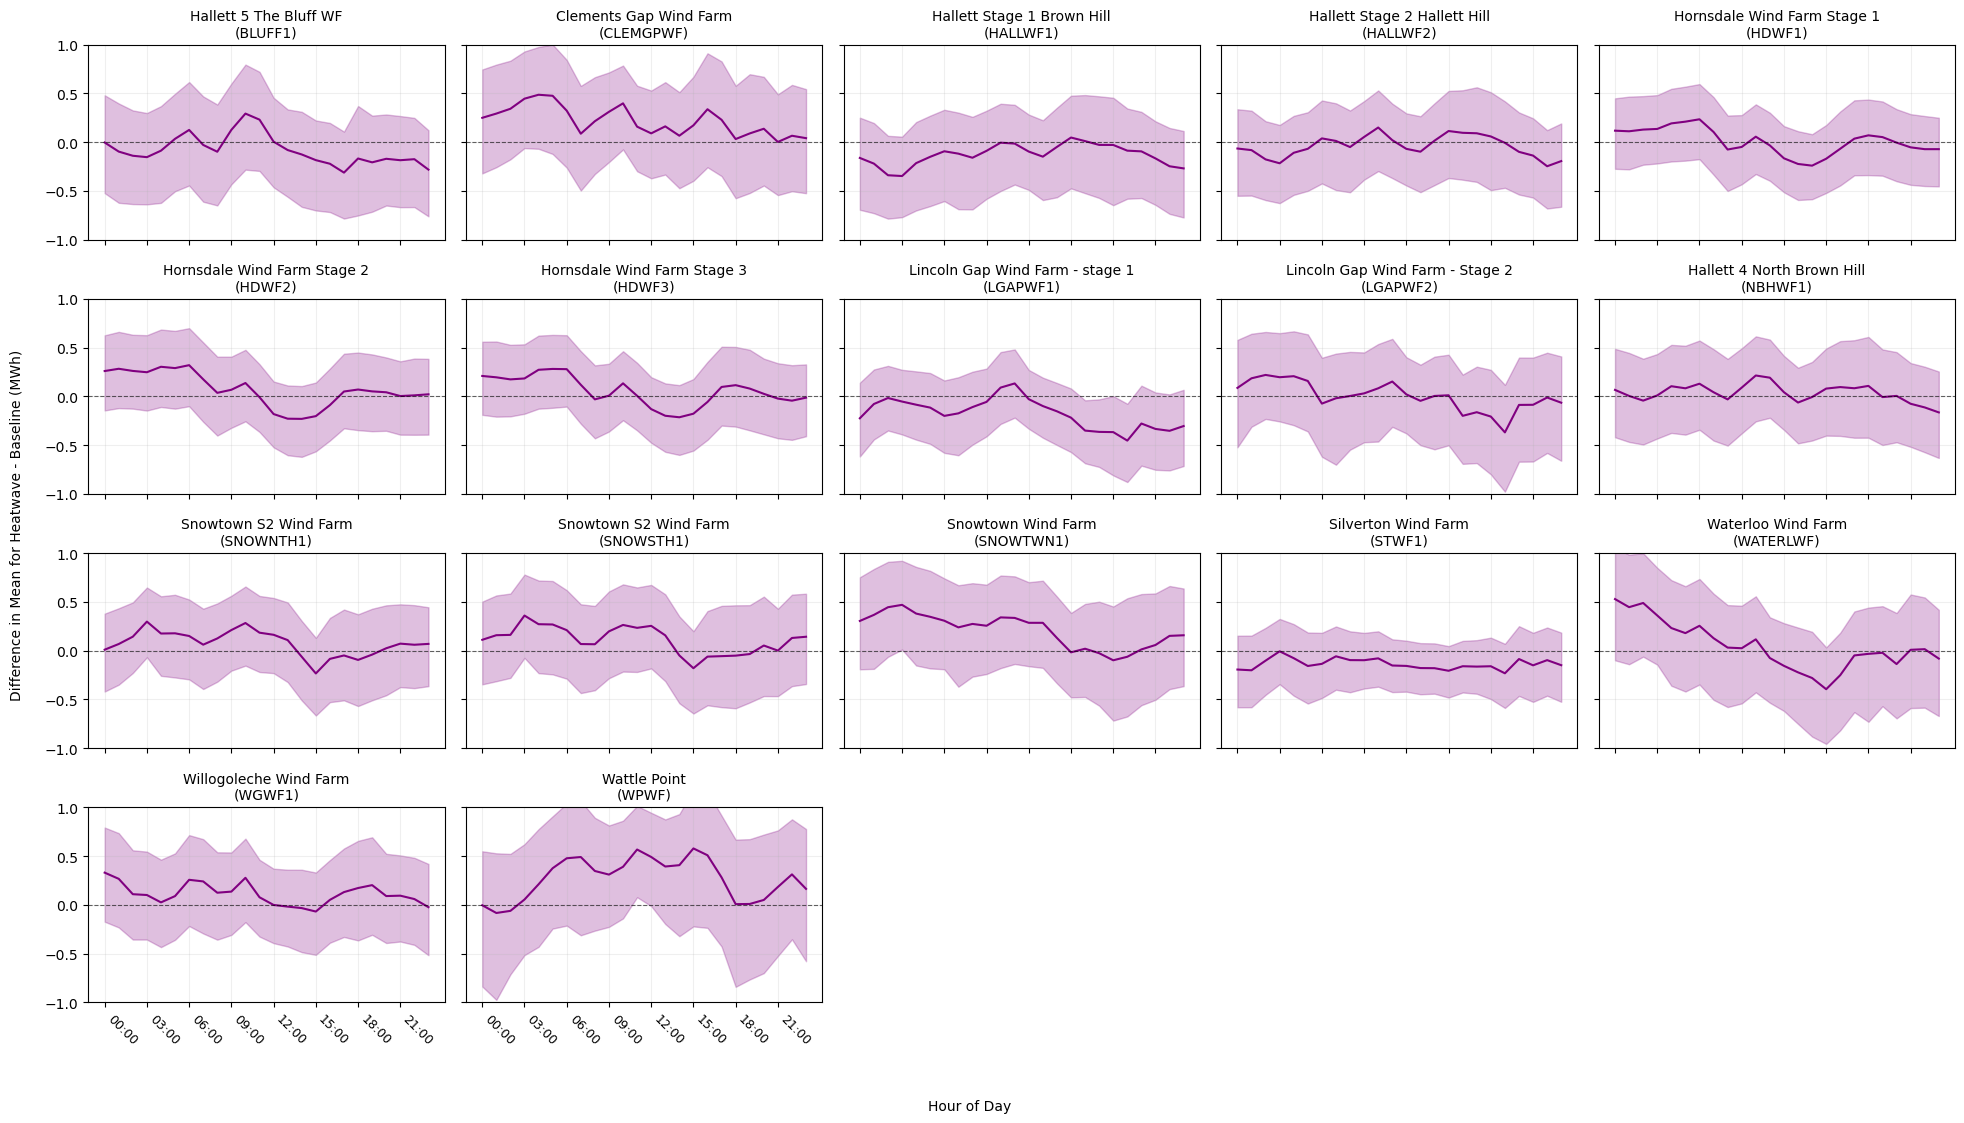

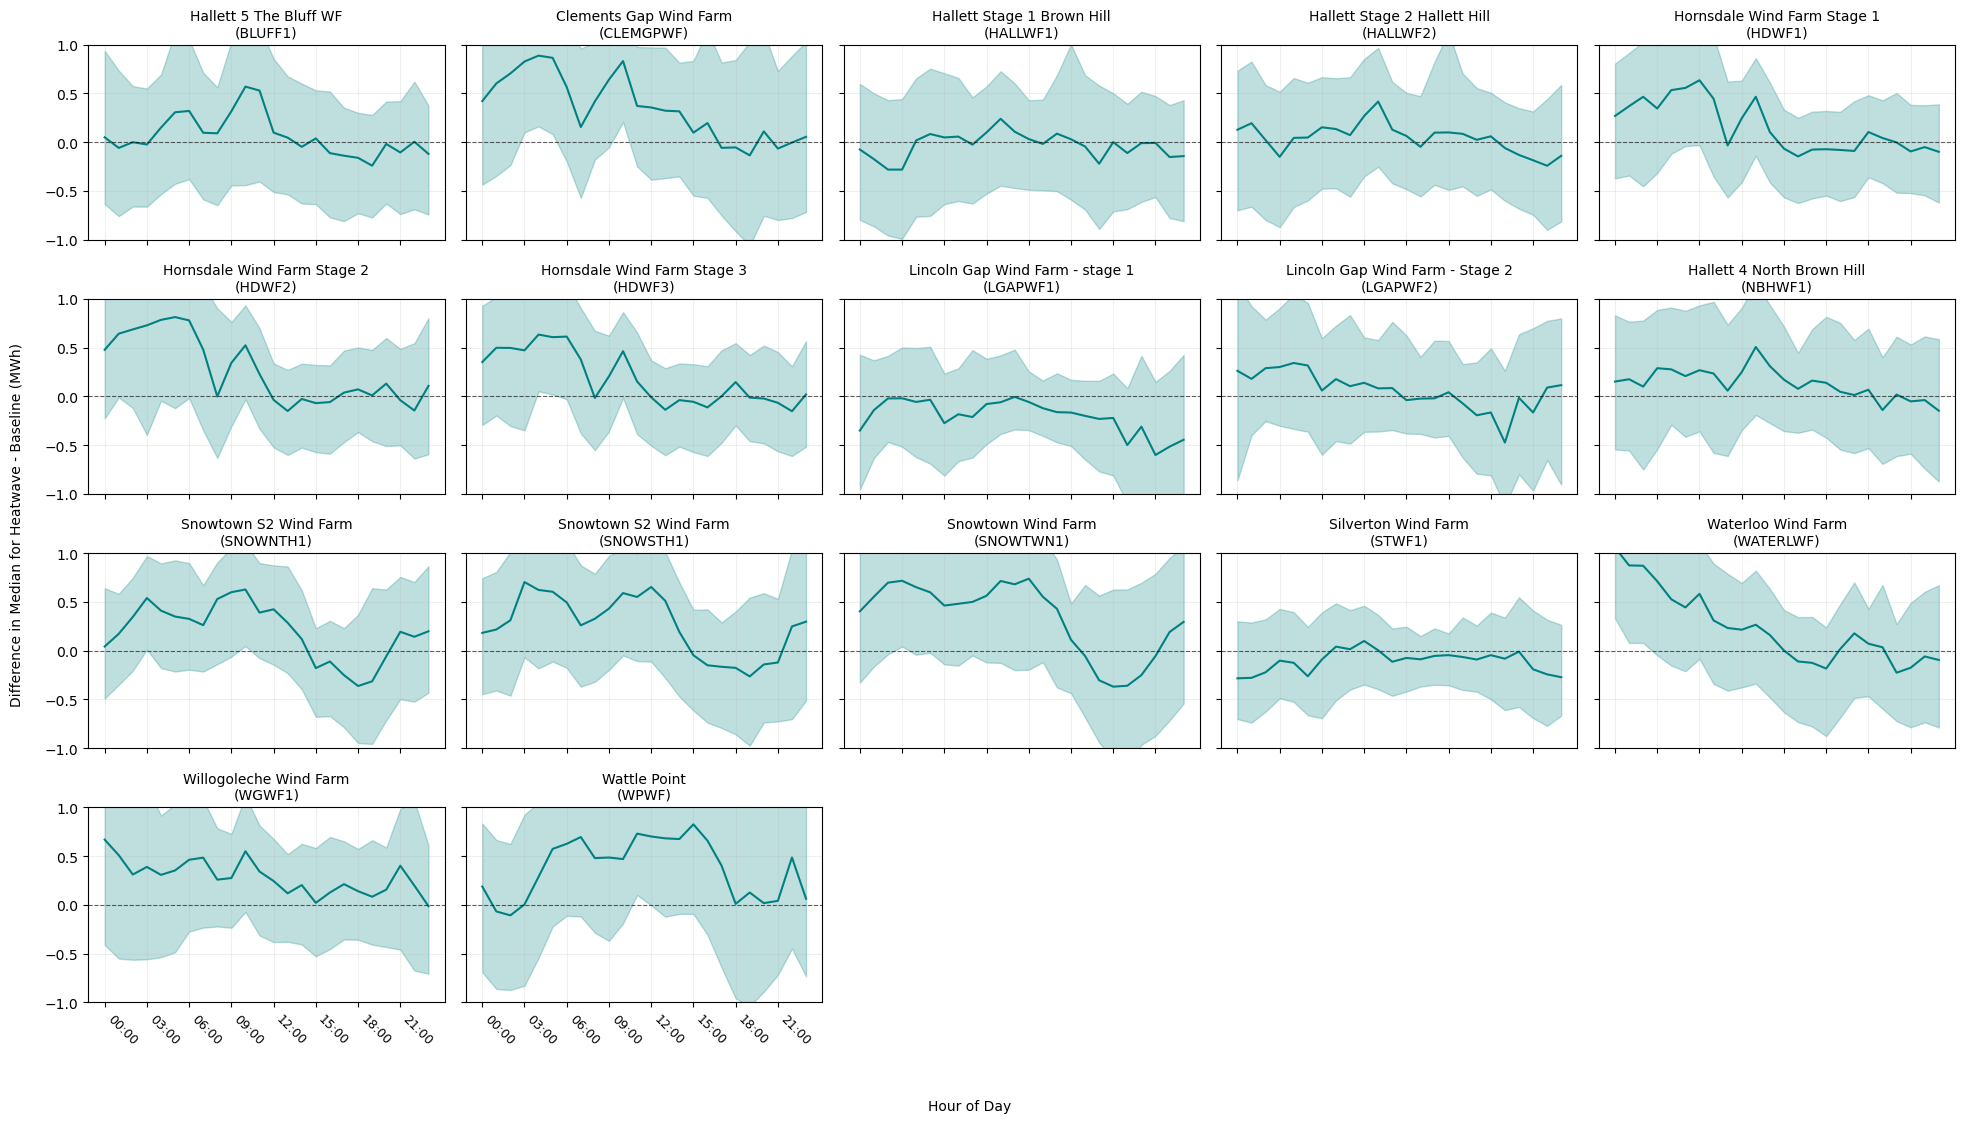

In [25]:
plot_duid_diffs_faceted(diff_results, ncols=5, cluster_name=0, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=5, cluster_name=0, metric="median")

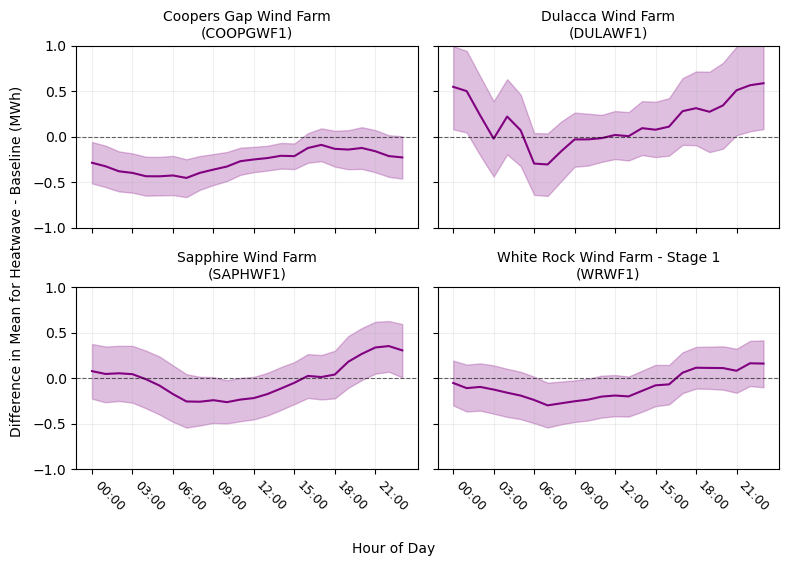

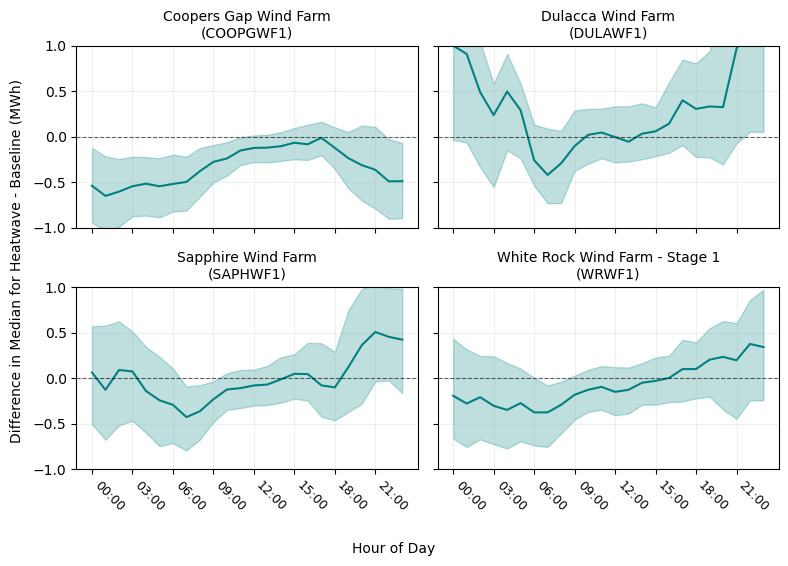

In [26]:
plot_duid_diffs_faceted(diff_results, ncols=2, cluster_name=1, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=2, cluster_name=1, metric="median")

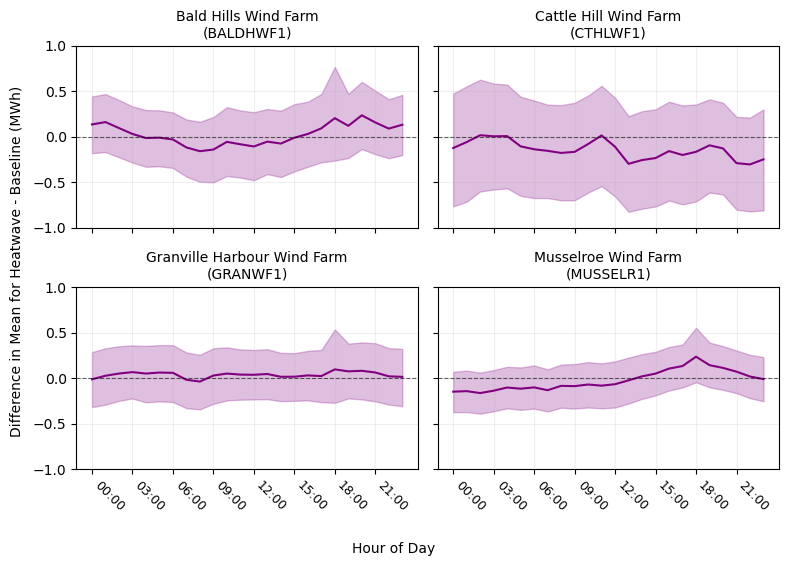

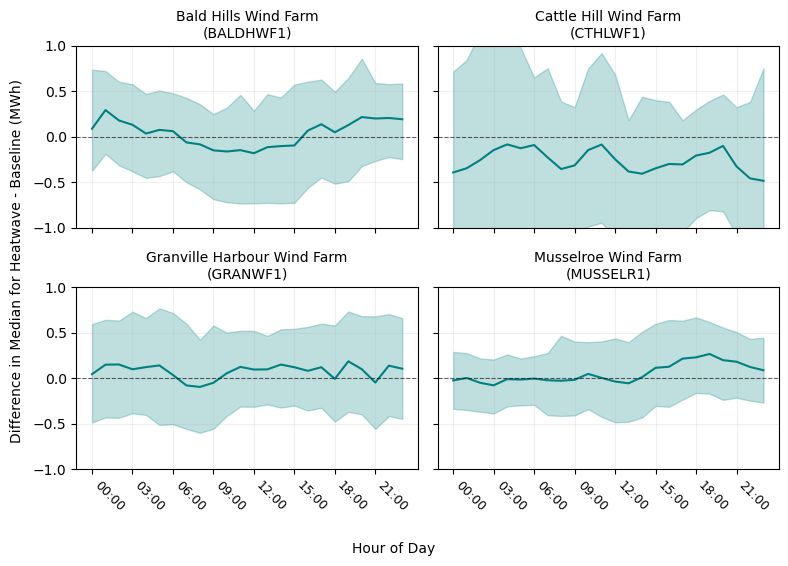

In [27]:
plot_duid_diffs_faceted(diff_results, ncols=2, cluster_name=2, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=2, cluster_name=2, metric="median")

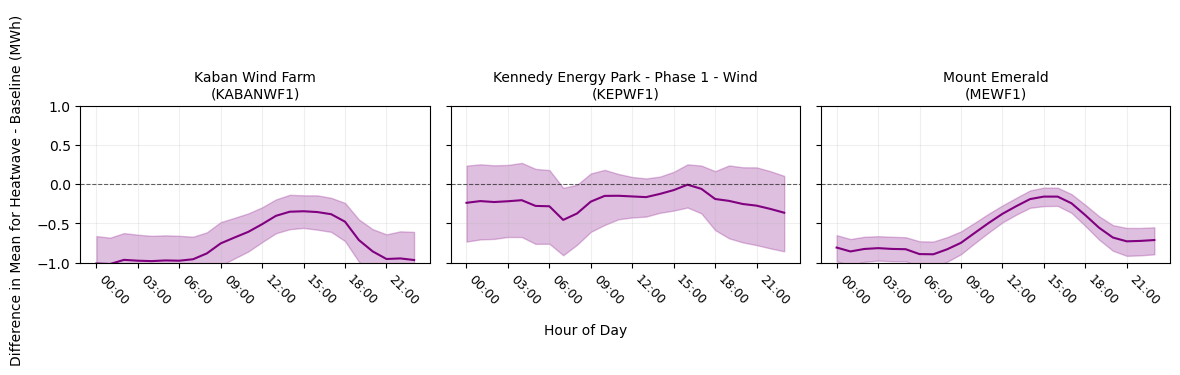

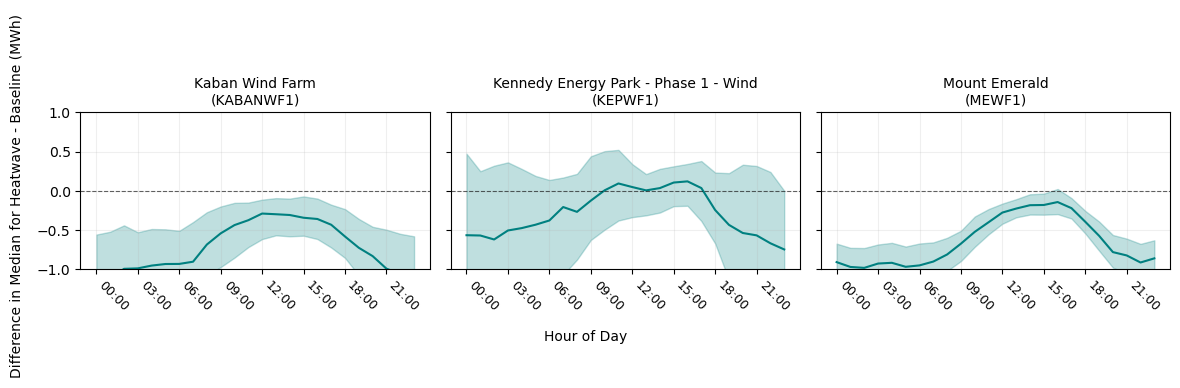

In [28]:
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=3, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=3, metric="median")

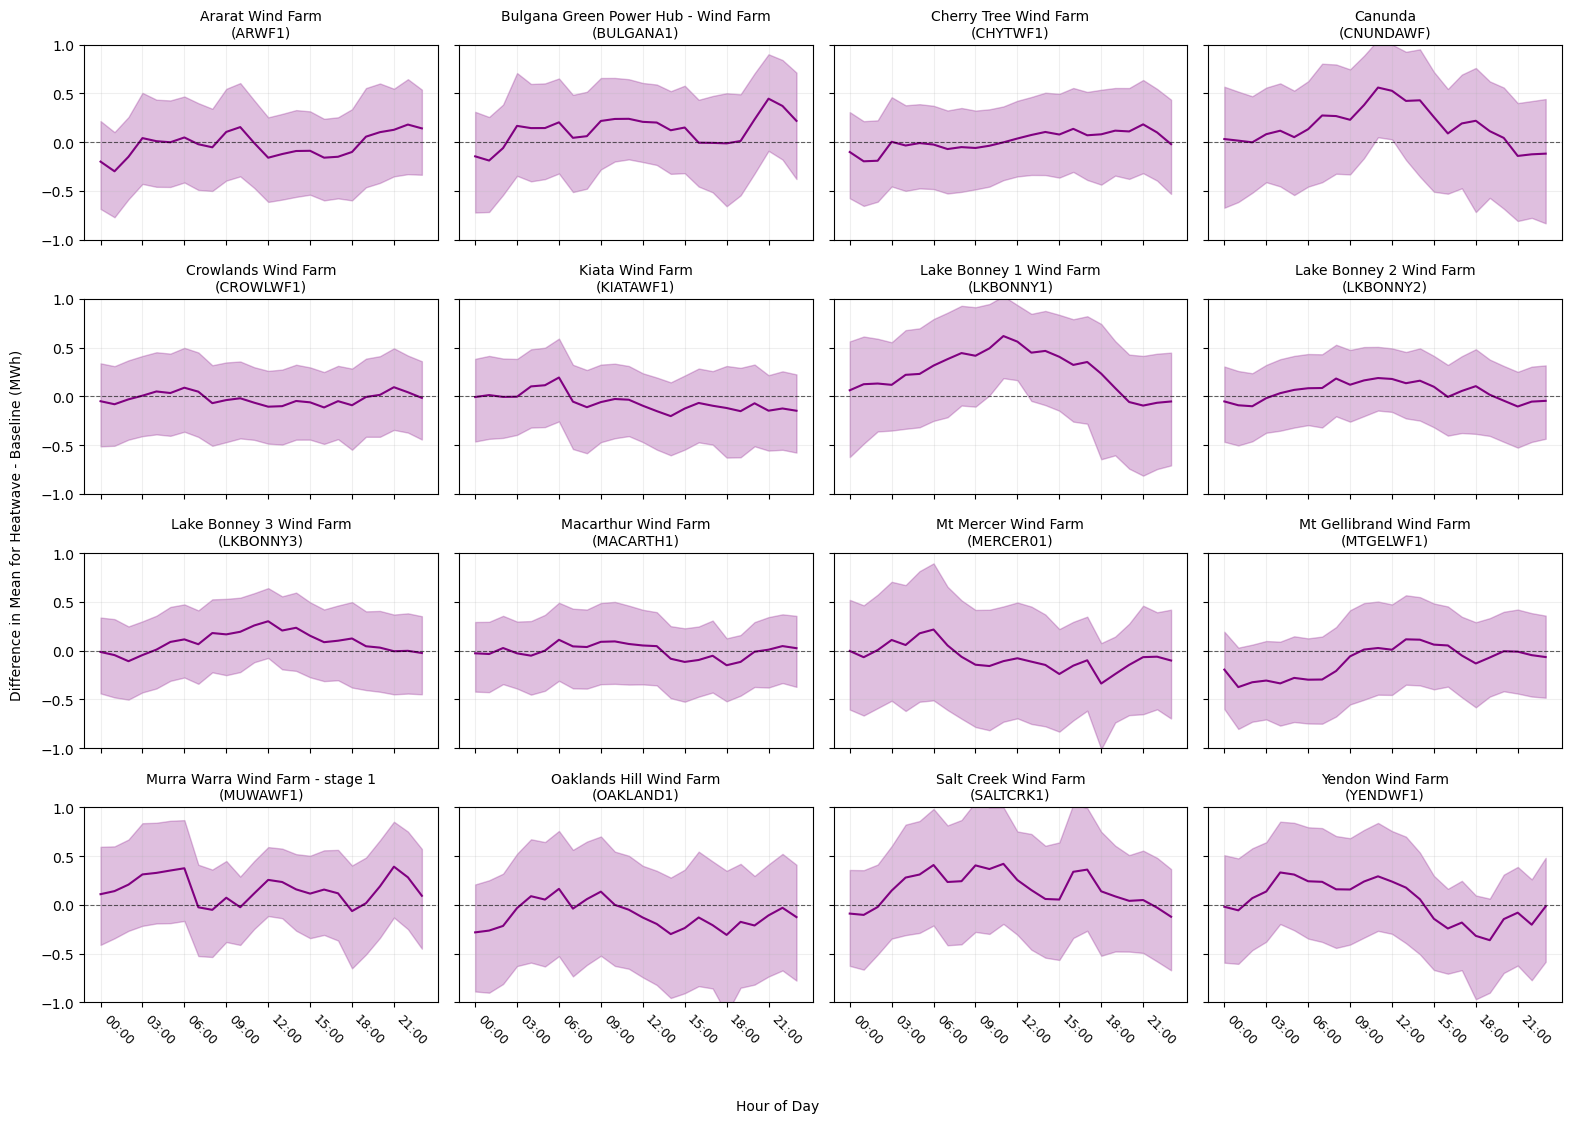

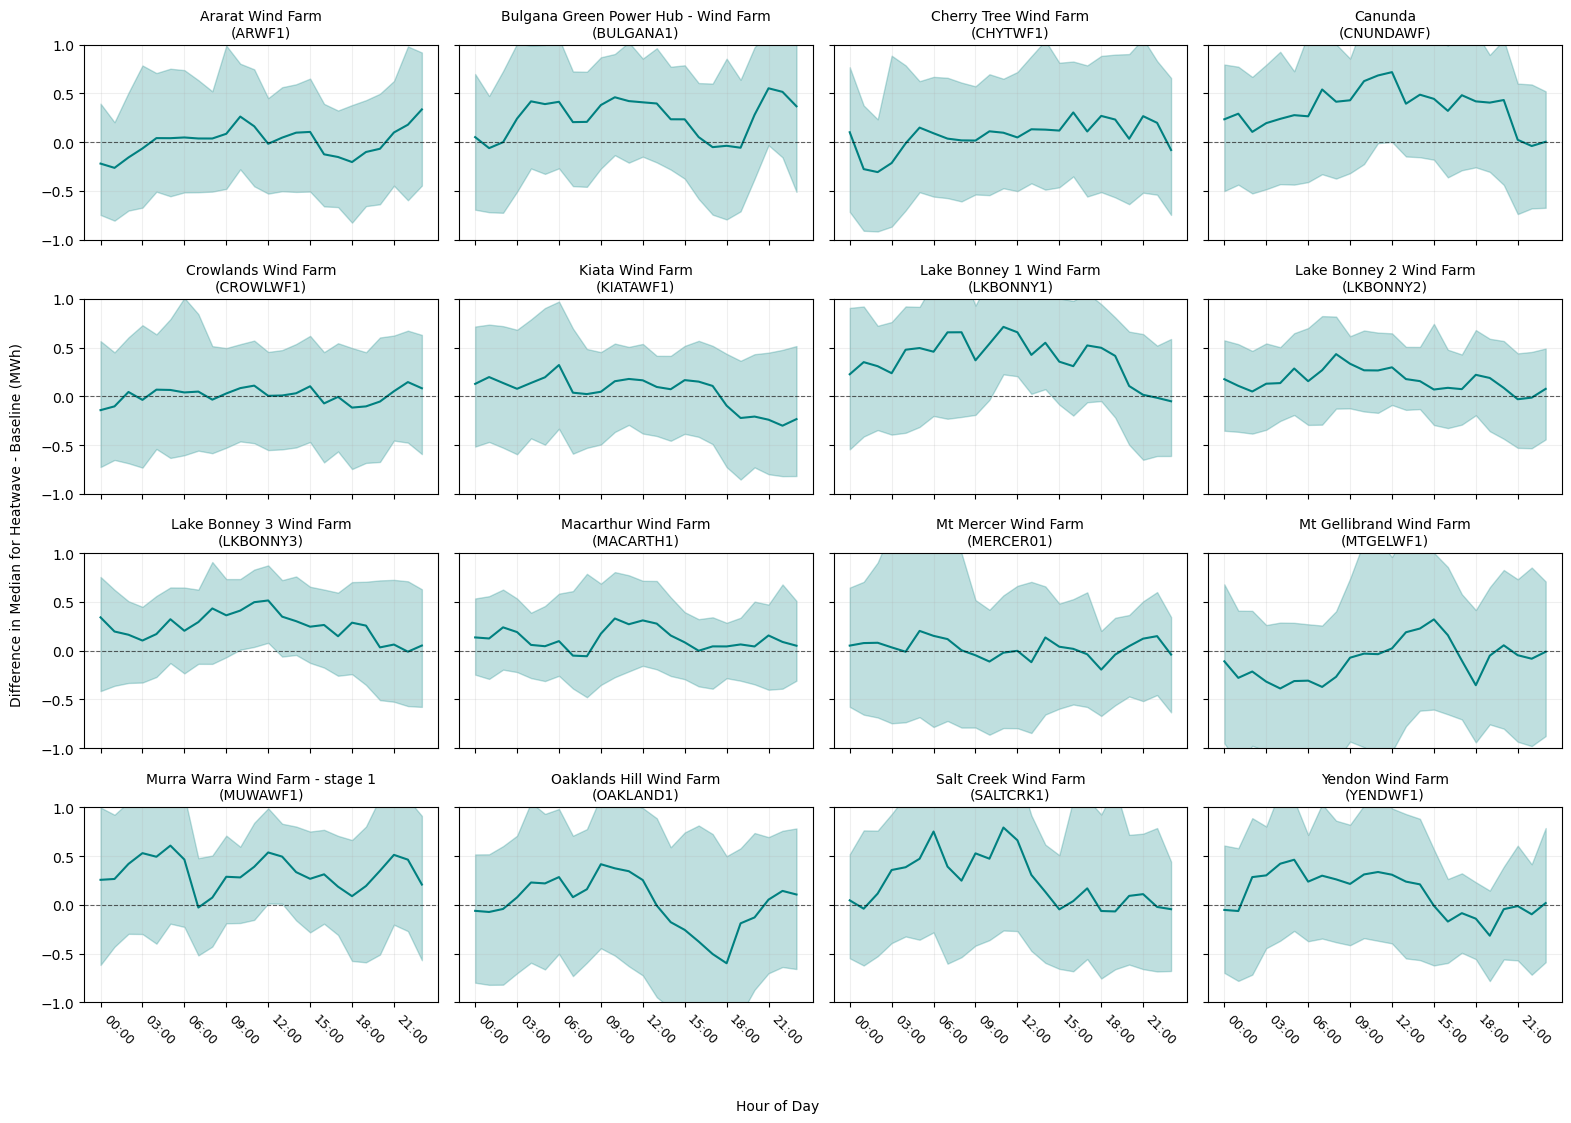

In [29]:
plot_duid_diffs_faceted(diff_results, ncols=4, cluster_name=4, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=4, cluster_name=4, metric="median")

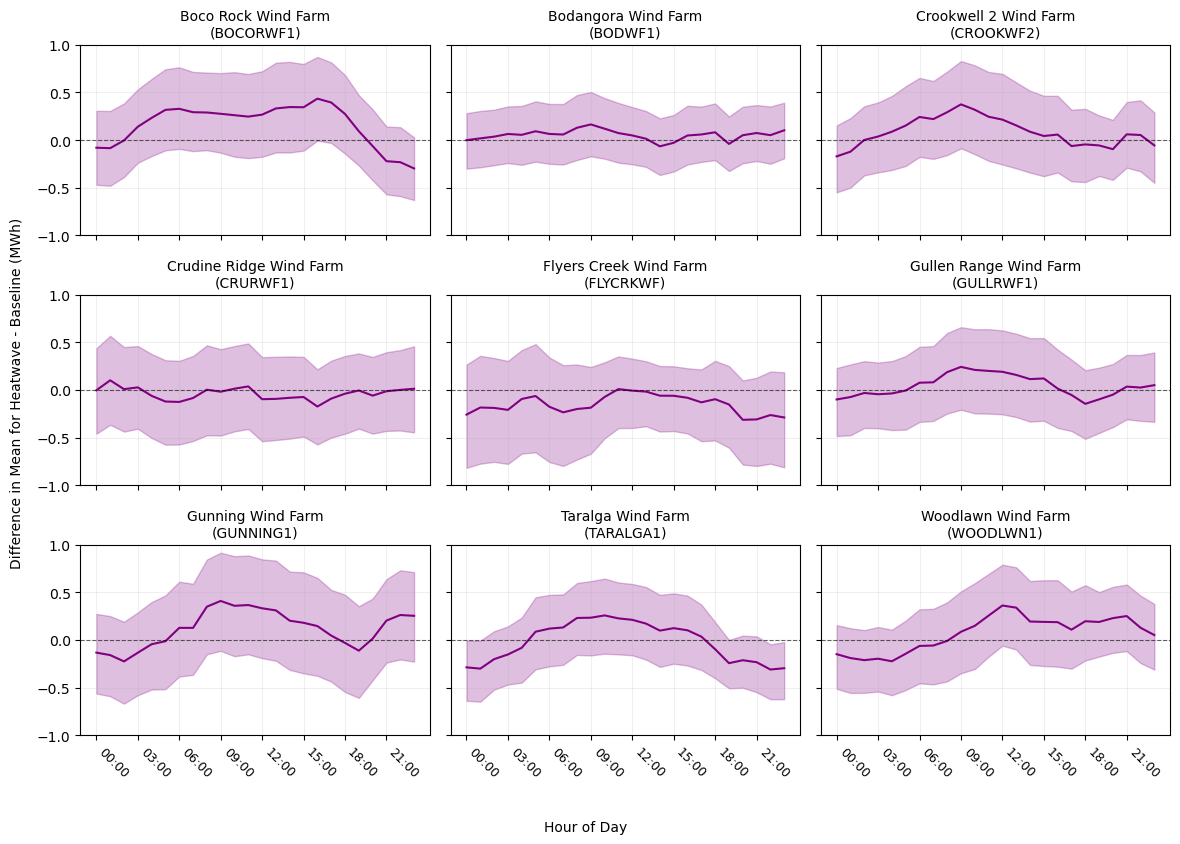

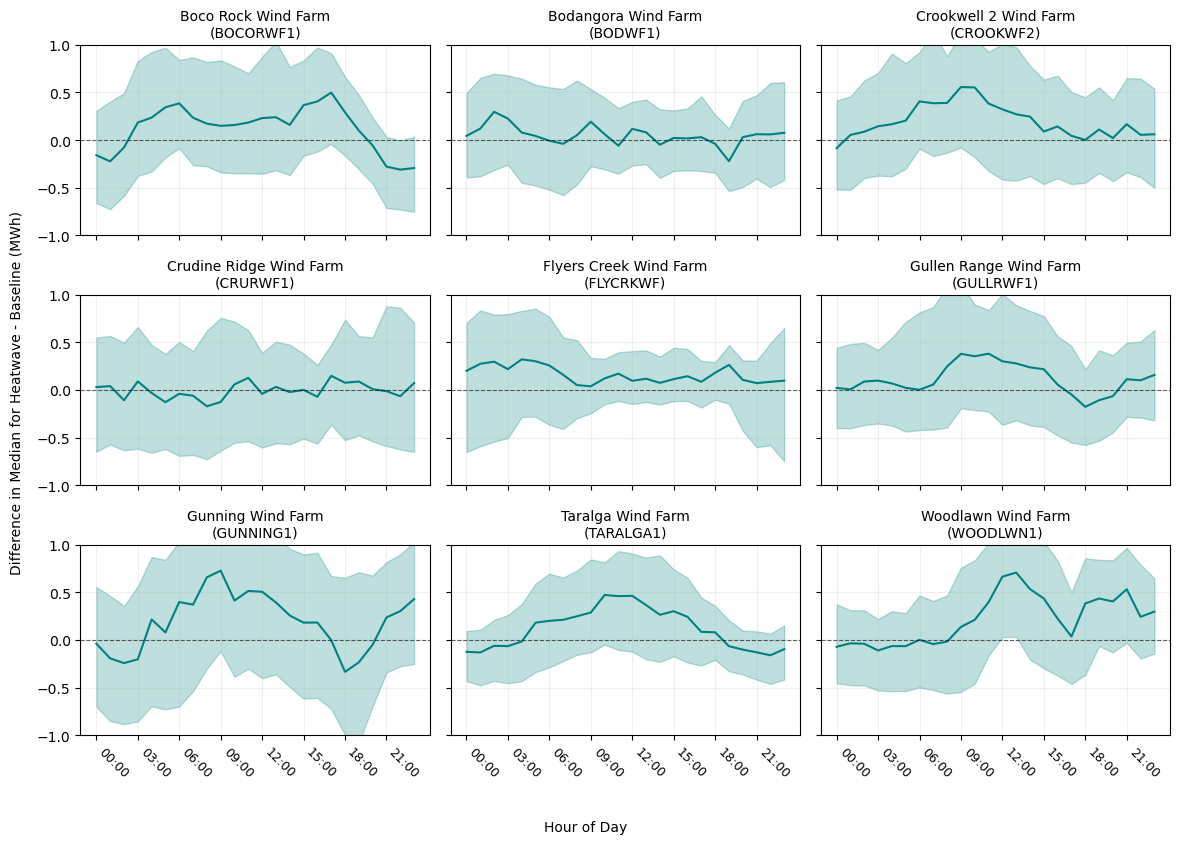

In [30]:
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=5, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=5, metric="median")

In [23]:
diff_results.to_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv', index=False)